# Lista de Exercícios

## Exercício 1:

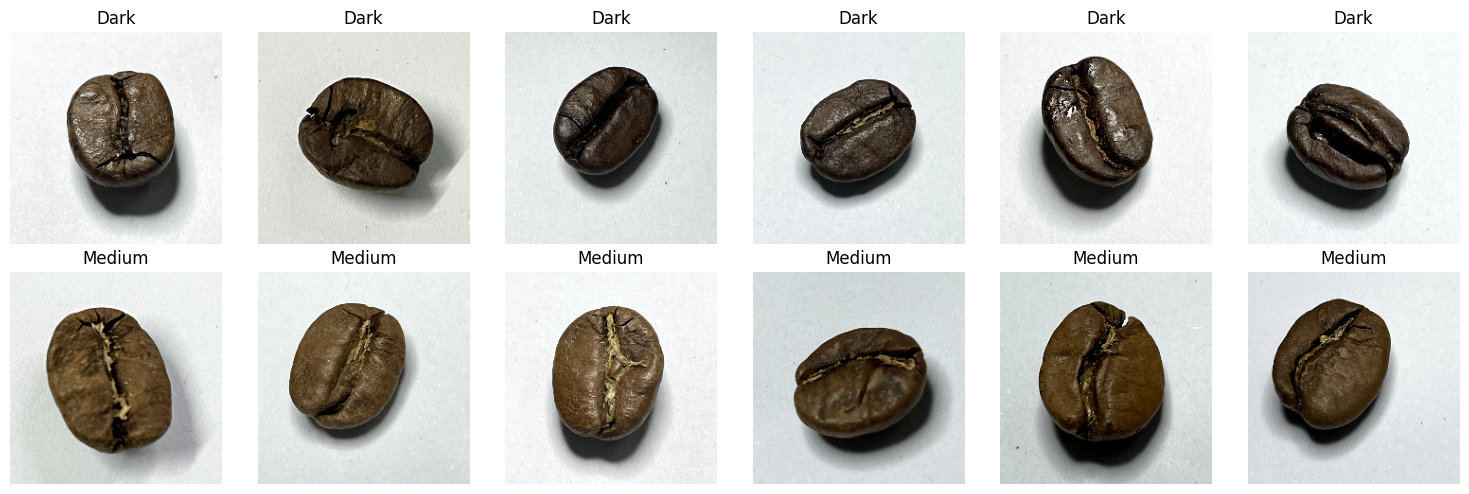

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


dark_path = "img/coffee/dark"
medium_path = "img/coffee/medium"

# 6 imgs de cada
dark_imgs = random.sample(os.listdir(dark_path), 6)
medium_imgs = random.sample(os.listdir(medium_path), 6)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# primeira linha vai ser 6 exemplares do café dark
for i, img_name in enumerate(dark_imgs):
    img = Image.open(os.path.join(dark_path, img_name))

    axes[0, i].imshow(img)
    axes[0, i].set_title("Dark")
    axes[0, i].axis("off")

# segunda linha café medium
for i, img_name in enumerate(medium_imgs):
    img = Image.open(os.path.join(medium_path, img_name))

    axes[1, i].imshow(img)
    axes[1, i].set_title("Medium")
    axes[1, i].axis("off")

plt.tight_layout()

# save das figuras
plt.savefig("amostras.png", dpi=300, bbox_inches="tight")

plt.show()

Com as imagens da para notar que o grão de café dark tem uma coloração mais escura enquanto os outros grãos possuem cor marrom mais clara e maior variação de cor.
Em questão de textura, aparetemente ambos os grãos são parecidos, não deu para notar tanto diferença.
Outro detalhe sobre o grão escuro, ele reflete melhor a luz.

## Exercício 2:

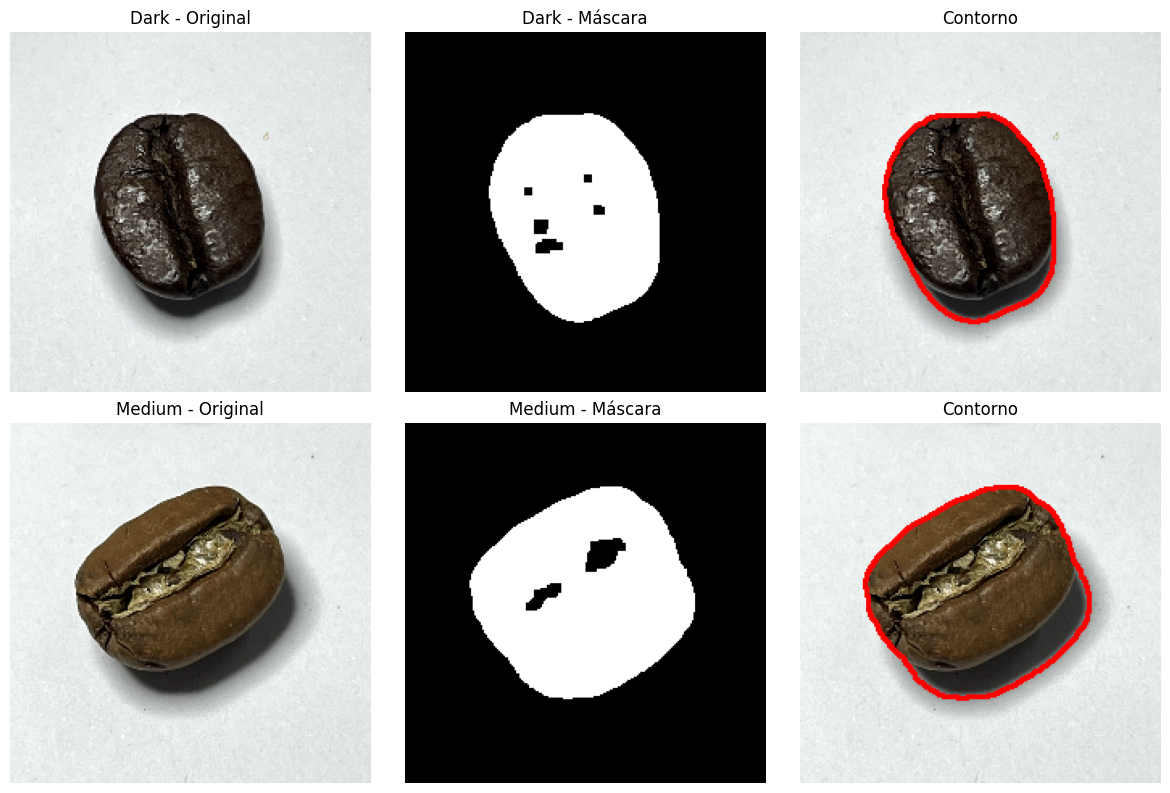

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar(caminho):
    bgr = cv2.imread(caminho)
    ## para cinza
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 0,255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

        mask_final = np.zeros_like(mask)
        mask_final[labels == largest_label] = 255
    else:
        mask_final = mask
    return bgr, gray, mask_final

img_dark = "img/coffee/dark/dark_001.png"
img_medium = "img/coffee/medium/medium_001.png"

amostras = [
    ("Dark", img_dark),
    ("Medium", img_medium)
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for linha, (classe, caminho) in enumerate(amostras):

    bgr, gray, mask = segmentar(caminho)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    contorno_img = rgb.copy()

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        contorno_img,
        contours,
        -1,
        (255, 0, 0),
        2
    )

    axes[linha, 0].imshow(rgb)
    axes[linha, 0].set_title(f"{classe} - Original")
    axes[linha, 0].axis("off")

    axes[linha, 1].imshow(mask, cmap="gray")
    axes[linha, 1].set_title(f"{classe} - Máscara")
    axes[linha, 1].axis("off")

    axes[linha, 2].imshow(contorno_img)
    axes[linha, 2].set_title("Contorno")
    axes[linha, 2].axis("off")

plt.tight_layout()
plt.savefig("segmentacao.png", dpi=300)
plt.show()

## Exercício 3:


In [10]:
import os
import cv2
import numpy as np
import pandas as pd



def segmentar(caminho):
    bgr = cv2.imread(caminho)
    ## para cinza
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 0,255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

        mask_final = np.zeros_like(mask)
        mask_final[labels == largest_label] = 255
    else:
        mask_final = mask

    return bgr, gray, mask_final

## pasta para possivel falhas
os.makedirs("falhas", exist_ok=True)

classes = {
    "dark": "img/coffee/dark",
    "medium": "img/coffee/medium"
}

resultado = []

for classe, pasta in classes.items():

    arquivos = [
        f for f in os.listdir(pasta)
        if f.endswith(".png")
    ]

    n_total = len(arquivos)
    n_falhas = 0

    for arquivo in arquivos:

        caminho = os.path.join(pasta, arquivo)

        bgr, gray, mask = segmentar(caminho)

        area_mascara = np.sum(mask == 255)

        altura, largura = mask.shape
        area_imagem = altura * largura

        falha = (area_mascara < 500 or area_mascara > 0.90 * area_imagem)

        if falha:

            n_falhas += 1

            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

            combinado = np.hstack((rgb, mask_rgb))

            cv2.imwrite(os.path.join("falhas", f"{classe}_{arquivo}"),
                cv2.cvtColor(combinado, cv2.COLOR_RGB2BGR)
            )

    resultado.append(
        [classe, n_falhas, n_total]
    )

tabela = pd.DataFrame(
    resultado,
    columns=[
        "classe",
        "n_falhas",
        "n_total"
    ]
)

print(tabela)

   classe  n_falhas  n_total
0    dark         0      150
1  medium         0      150


## Exercício 4:


In [11]:
import cv2
import numpy as np
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

def segmentar(caminho):
    bgr = cv2.imread(caminho)
    ## para cinza
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 0,255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

        mask_final = np.zeros_like(mask)
        mask_final[labels == largest_label] = 255
    else:
        mask_final = mask

    return bgr, gray, mask_final

def features_grao(caminho):
    bgr, gray, mask = segmentar(caminho)

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    pix = mask == 255

    H_mean = np.mean(H[pix])
    S_mean = np.mean(S[pix])
    V_mean = np.mean(V[pix])

    frac_dark = np.sum(V[pix] < 80) / np.sum(pix)

    props = regionprops(mask.astype(int))

    regiao = props[0]

    area = regiao.area

    perimetro = regiao.perimeter

    circularidade = (4 * np.pi * area / (perimetro ** 2)) if perimetro > 0 else 0

    solidity = regiao.solidity

    eccentricity = regiao.eccentricity

    gray_masked = gray.copy()
    gray_masked[~pix] = 0

    glcm = graycomatrix(
        gray_masked,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contraste = graycoprops(glcm,"contrast")[0, 0]

    homogeneidade = graycoprops(glcm,"homogeneity")[0, 0]


    lbp = local_binary_pattern(gray_masked,P=8,R=1,method="uniform")

    lbp_var = np.var(lbp[pix])

    return {

       ##cor
        "H_mean": H_mean,
        "S_mean": S_mean,
        "V_mean": V_mean,
        "frac_dark": frac_dark,


        "area": area,
        "circularidade": circularidade,
        "solidity": solidity,
        "eccentricity": eccentricity,


        "contraste": contraste,
        "homogeneidade": homogeneidade,
        "lbp_var": lbp_var
    }




print("DARK")
print(
    features_grao(
        "img/coffee/dark/dark_001.png"
    )
)

print("\nMEDIUM")
print(
    features_grao(
        "img/coffee/medium/medium_001.png"
    )
)

DARK
{'H_mean': np.float64(19.422032434507244), 'S_mean': np.float64(89.27252662892236), 'V_mean': np.float64(54.59360905863161), 'frac_dark': np.float64(0.8021303137894635), 'area': np.float64(10421.0), 'circularidade': np.float64(0.4282832622959125), 'solidity': np.float64(0.9593114241001565), 'eccentricity': 0.6424686676390324, 'contraste': np.float64(211.6077434336964), 'homogeneidade': np.float64(0.8098609478902462), 'lbp_var': np.float64(10.197184806932619)}

MEDIUM
{'H_mean': np.float64(20.882760794201072), 'S_mean': np.float64(122.16947683580209), 'V_mean': np.float64(76.00063031831074), 'frac_dark': np.float64(0.5230854081311062), 'area': np.float64(12692.0), 'circularidade': np.float64(0.4523140962556854), 'solidity': np.float64(0.945611682312621), 'eccentricity': 0.40108122435476984, 'contraste': np.float64(190.2957238949392), 'homogeneidade': np.float64(0.7771927867844796), 'lbp_var': np.float64(9.994752117093793)}


## Exercício 5:


In [12]:
import os
import pandas as pd

dados = []
descartes = 0

classes = {
    "dark": "img/coffee/dark",
    "medium": "img/coffee/medium"
}

for classe, pasta in classes.items():

    arquivos = [
        f for f in os.listdir(pasta)
        if f.endswith(".png")
    ]

    for arquivo in arquivos:

        caminho = os.path.join(pasta, arquivo)

        try:

            feat = features_grao(caminho)

            if feat is None:
                descartes += 1
                continue

            feat["classe"] = classe
            feat["caminho"] = caminho

            dados.append(feat)

        except Exception:
            descartes += 1

df = pd.DataFrame(dados)

df.to_csv(
    "features.csv",
    index=False
)

print("Shape:", df.shape)
print("Descartes:", descartes)

print("\nDistribuição por classe:")
print(df["classe"].value_counts())

Shape: (300, 13)
Descartes: 0

Distribuição por classe:
classe
dark      150
medium    150
Name: count, dtype: int64


## Exercício 6:


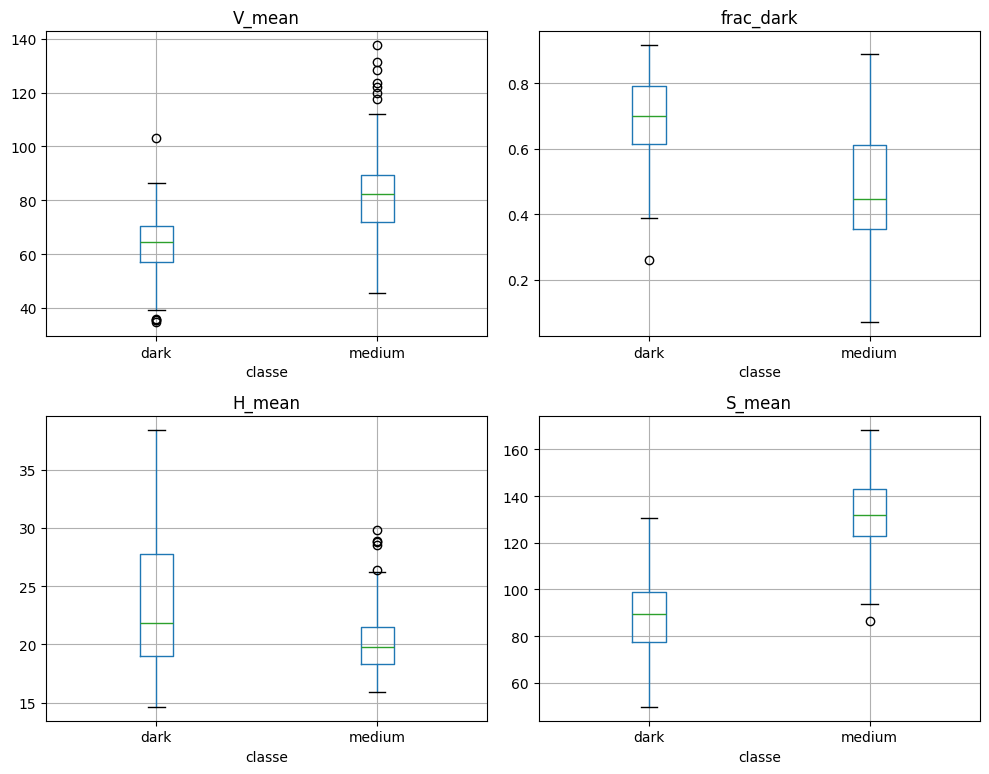

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("features.csv")

features_boxplot = [
    "V_mean",
    "frac_dark",
    "H_mean",
    "S_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), features_boxplot):

    df.boxplot(
        column=feature,
        by="classe",
        ax=ax
    )

    ax.set_title(feature)

plt.suptitle("")
plt.tight_layout()

plt.savefig("boxplots.png", dpi=300)

plt.show()

In [16]:
from scipy.stats import mannwhitneyu

features = [
    c for c in df.columns
    if c not in ["classe", "caminho"]
]

resultado = []

for feature in features:

    dark = df[df["classe"] == "dark"][feature]

    medium = df[df["classe"] == "medium"][feature]

    _, p = mannwhitneyu(
        dark,
        medium,
        alternative="two-sided"
    )

    resultado.append(
        [feature, p]
    )

resultado = pd.DataFrame(
    resultado,
    columns=["feature", "p_valor"]
)

resultado = resultado.sort_values(
    by="p_valor"
)

print(resultado.head(5))

      feature       p_valor
1      S_mean  9.927640e-46
2      V_mean  6.012293e-20
3   frac_dark  6.799575e-20
0      H_mean  2.607872e-06
10    lbp_var  1.774762e-04


## Exercício 7:


In [19]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif, RFECV, SelectFromModel

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


## panda para ler o dataset
df = pd.read_csv("features.csv")

X = df.drop(
    columns=["classe", "caminho"]
)

y = df["classe"]


## melhores scores
filter_selector = SelectKBest(
    score_func=f_classif,
    k=5
)

filter_selector.fit(X, y)

filter_features = X.columns[
    filter_selector.get_support()
].tolist()


#wraperRFECV
svm = SVC(
    kernel="linear"
)

rfecv = RFECV(
    estimator=svm,
    step=1,
    cv=3,
    scoring="accuracy"
)

rfecv.fit(X, y)

wrapper_features = X.columns[
    rfecv.support_
].tolist()


# randomforest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

embedded_selector = SelectFromModel(
    rf,
    threshold="median"
)

embedded_selector.fit(X, y)

embedded_features = X.columns[
    embedded_selector.get_support()
].tolist()



consenso = sorted(
    set(filter_features)
    &
    set(wrapper_features)
    &
    set(embedded_features)
)



print("FILTER")
print(filter_features)

print("\nWRAPPER")
print(wrapper_features)

print("\nEMBEDDED")
print(embedded_features)

print("\nCONSENSO")
print(consenso)

ImportError: DLL load failed while importing _cyutility: Uma política de Controle de Aplicativo bloqueou este arquivo.

In [24]:
resultado = pd.DataFrame({
    "filter": pd.Series(filter_features),
    "wrapper": pd.Series(wrapper_features),
    "embedded": pd.Series(embedded_features)
})

print(resultado)

print("\nCONSENSO:")
print(consenso)

      filter        wrapper       embedded
0     H_mean         H_mean         H_mean
1     S_mean         S_mean         S_mean
2     V_mean      frac_dark         V_mean
3  frac_dark  circularidade      frac_dark
4    lbp_var       solidity      contraste
5        NaN   eccentricity  homogeneidade
6        NaN  homogeneidade            NaN
7        NaN        lbp_var            NaN

CONSENSO:
['H_mean', 'S_mean', 'frac_dark']


## Exercício 8:


In [26]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold,cross_validate)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier



## panda para ler o dataset
df = pd.read_csv("features.csv")

X = df.drop(
    columns=["classe", "caminho"]
)

y = df["classe"]


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


modelos = {

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),

    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf"))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


resultados = []
## melhores resultados
for nome, modelo in modelos.items():

    scores = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "f1_macro"
        ]
    )

    resultados.append({

        "modelo": nome,

        "acc_mean":
            np.mean(
                scores["test_accuracy"]
            ),

        "acc_std":
            np.std(
                scores["test_accuracy"]
            ),

        "f1_mean":
            np.mean(
                scores["test_f1_macro"]
            ),

        "f1_std":
            np.std(
                scores["test_f1_macro"]
            )
    })




resultado_df = pd.DataFrame(
    resultados
)

resultado_df = resultado_df.sort_values(
    by="acc_mean",
    ascending=False
)

print(resultado_df)

               modelo  acc_mean   acc_std   f1_mean    f1_std
3        RandomForest  0.950000  0.021082  0.949964  0.021088
2             SVM_RBF  0.946667  0.026667  0.946646  0.026670
1  LogisticRegression  0.940000  0.022608  0.939942  0.022626
0                 KNN  0.936667  0.022111  0.936597  0.022125


## Exercício 9:


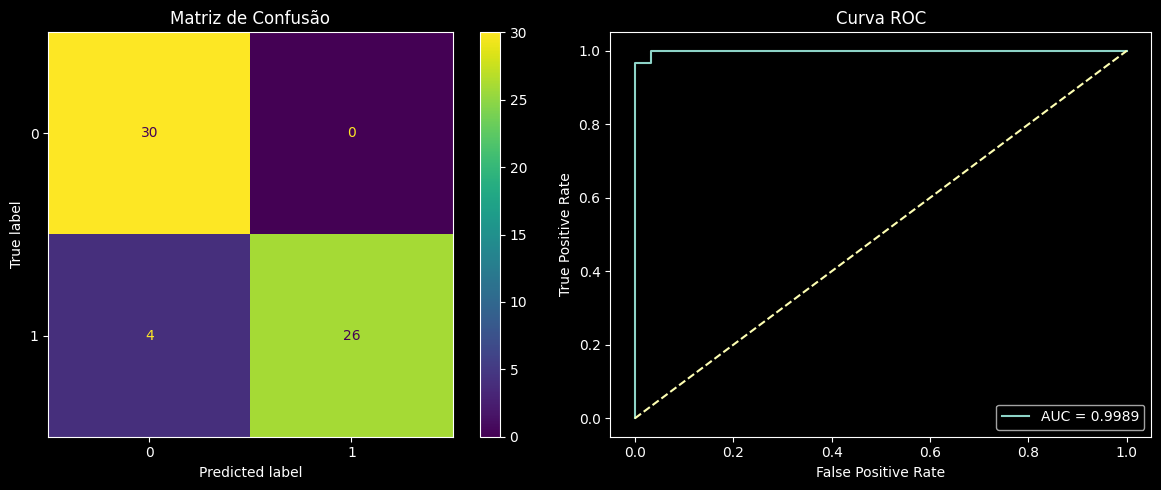

              precision    recall  f1-score   support

        dark       0.88      1.00      0.94        30
      medium       1.00      0.87      0.93        30

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_curve,roc_auc_score)

from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("features.csv")

X = df.drop(
    columns=["classe", "caminho"]
)

y = df["classe"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


y_prob = modelo.predict_proba(X_test)[:, 1]

y_bin = (y_test == "medium").astype(int)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=axes[0])

axes[0].set_title(
    "Matriz de Confusão"
)

fpr, tpr, _ = roc_curve(
    y_bin,
    y_prob
)

auc = roc_auc_score(
    y_bin,
    y_prob
)

axes[1].plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "--"
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].set_title(
    "Curva ROC"
)

axes[1].legend()

plt.tight_layout()

plt.savefig(
    "matriz_roc.png",
    dpi=300
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

## Exercício 10:

                            caminho    real previsto  prob
0  img/coffee/medium\medium_029.png  medium     dark  0.70
1  img/coffee/medium\medium_143.png  medium     dark  0.64
2  img/coffee/medium\medium_075.png  medium     dark  0.66
3  img/coffee/medium\medium_144.png  medium     dark  0.60


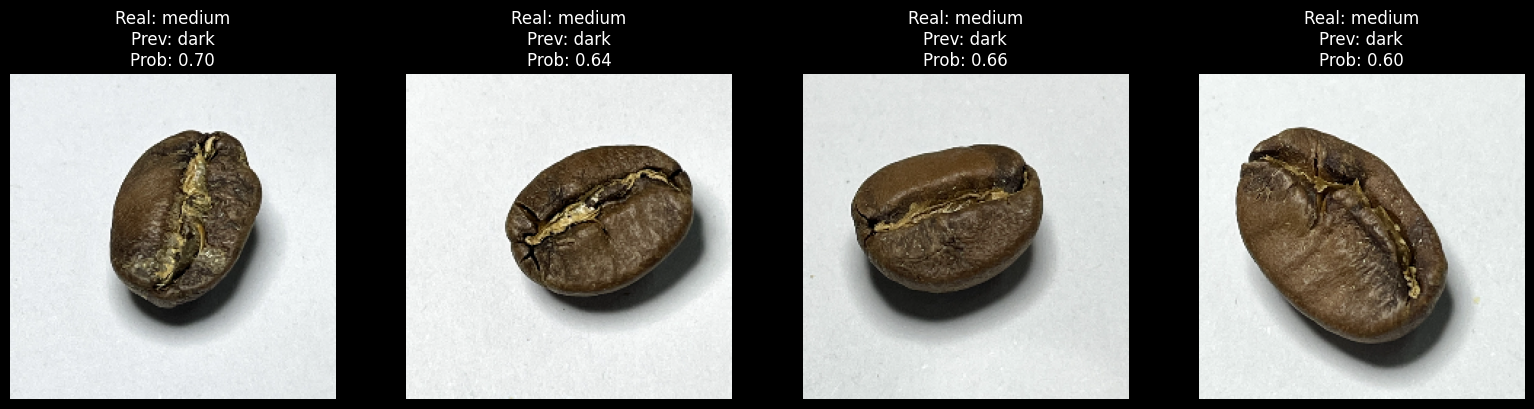

In [28]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv("features.csv")

X = df.drop(
    columns=["classe", "caminho"]
)

y = df["classe"]

caminhos = df["caminho"]


X_train, X_test, y_train, y_test, path_train, path_test = train_test_split(
    X,
    y,
    caminhos,
    test_size=0.20,
    stratify=y,
    random_state=42
)



modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

y_prob = modelo.predict_proba(X_test)


erros = []

for i in range(len(y_test)):

    if y_test.iloc[i] != y_pred[i]:

        classe_prevista = y_pred[i]

        idx_classe = list(
            modelo.classes_
        ).index(classe_prevista)

        prob = y_prob[i][idx_classe]

        erros.append({
            "caminho": path_test.iloc[i],
            "real": y_test.iloc[i],
            "previsto": classe_prevista,
            "prob": prob
        })


erros = erros[:5]


tabela_erros = pd.DataFrame(erros)

print(tabela_erros)



if len(erros) > 0:

    fig, axes = plt.subplots(
        1,
        len(erros),
        figsize=(4 * len(erros), 4)
    )

    if len(erros) == 1:
        axes = [axes]

    for ax, erro in zip(axes, erros):

        img = cv2.imread(
            erro["caminho"]
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(img)

        ax.set_title(
            f"Real: {erro['real']}\n"
            f"Prev: {erro['previsto']}\n"
            f"Prob: {erro['prob']:.2f}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        "erros_classificacao.png",
        dpi=300
    )

    plt.show()

else:

    print(
        "Nenhuma imagem foi classificada incorretamente."
    )

## Exercício 11:

O modelo que eu implantaria em produção seria o Random Forest. Entre os quatro modelos avaliados, ele apresentou a maior acurácia média (95,0%) e o maior F1-score médio (95,0%), indicando melhor capacidade de distinguir grãos medium e dark. Sua latência de predição é baixa, permitindo o uso em tempo real na esteira de produção. Embora sua interpretabilidade seja menor que a da Regressão Logística, ainda é possível analisar a importância das features para compreender quais características influenciam as decisões. Além disso, o custo computacional de retreinamento é reduzido devido ao pequeno conjunto de dados e ao número limitado de atributos. Dessa forma, o Random Forest oferece o melhor equilíbrio entre desempenho, velocidade e viabilidade operacional.
